In [1]:
import os
import h5py
import numpy as np
import scipy.stats as ss
from vamana.utils import load_samples
from vamana.postprocess import compute_mchq_pdfs, compute_intervals
from vamana.models import calculate_norm_m1m2

import vamana.conversions as conversions

%matplotlib inline
import seaborn
import matplotlib as mpl
import matplotlib.pyplot as plt 
from matplotlib.ticker import FormatStrFormatter

In [2]:
plt.rcParams.update({
    "text.usetex": False,           # Keeps it stable without LaTeX install
    "mathtext.fontset": "stix",     # STIX looks almost identical to Times/ApJ math
    "font.family": "STIXGeneral",   # Use the STIX version of Times
    "axes.unicode_minus": False,    # Fixes the [U+2212] missing glyph error
    "font.size": 15,                # Standard ApJ font size
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
dpi = 200

colours = {}
colours['o4b'] = '#5E3C99'
colours['o4b_gap'] = '#1f77b4'

In [3]:
# Load all parameters
fname = './results/GWTC5.hdf5'
samples = load_samples(fname)
samples_gap = load_samples('./results/GWTC5_gap.hdf5')

# Access parameters
print(samples['log_post'].shape)   # (nsamples,)
print(np.unique(samples['log_post']).shape)   # (nsamples,)

(4200,)
(4200,)


In [4]:
samples.keys()

dict_keys(['kcomp', 'kpop', 'log_post', 'mu_m1', 'mu_m2', 'mu_sz', 'rate', 'rho_m1m2', 'sigma_over_mu_m1_pow_beta', 'sigma_over_mu_m2_pow_beta', 'sigma_sz', 'weights'])

In [5]:
npost = len(samples['log_post'])
ncomp = len(samples['weights'][0])

In [6]:
directory = './plots/' + fname.split('/')[-1][:-5]
print (directory)
if not os.path.exists(directory):
    os.makedirs(directory)

./plots/GWTC5


### Plot the modeled mass parameters

In [7]:
# Calculate density on the component mass plane. Also calculate factor increase in merger rate between z=0 and z=0.5
mass_ax = np.linspace(1.0, 101.0, 501)
m1m2_xy, m1m2_yx = np.meshgrid(mass_ax, mass_ax)

mean_dRdm1dm2 = 0
pdfs_m1, pdfs_m2, pdfs_m = [], [], [] #Primary, Secondary, Component
rate_ratio_m1 = []
rate_ratio_m2 = []
mean_dRdm1dm2 = 0
idx = np.where(m1m2_yx / m1m2_xy > 1)
XYYX = np.dstack((m1m2_xy, m1m2_yx))

for n in range(npost):
    mu_m1 = samples['mu_m1'][n]
    mu_m2 = samples['mu_m2'][n]
    sig_m1 = samples['sigma_over_mu_m1_pow_beta'][n] * mu_m1
    sig_m2 = samples['sigma_over_mu_m2_pow_beta'][n] * mu_m2
    corr_m1m2 = samples['rho_m1m2'][n]
    gwts = samples['weights'][n]
    rate = samples['rate'][n]
    k = samples['kcomp'][n]
    pdf_m1m2, dRdm1dm2_at_z = 0, 0
    if n % 500 == 0:
        print (n)
    for jj in range(ncomp):
        mean = np.array([mu_m1[jj], mu_m2[jj]])
        cov = np.diag([sig_m1[jj] ** 2, sig_m2[jj] ** 2])
        cov[0][1] = cov[1][0] = corr_m1m2[jj] * sig_m1[jj] * sig_m2[jj]
        
        norm_m1m2 = calculate_norm_m1m2(mean, cov)
        pdf = ss.multivariate_normal.pdf(XYYX, mean = mean, cov = cov)
        pdf[idx] = 0
        pdf /= norm_m1m2
        weighted_pdf = pdf * gwts[jj]
        pdf_m1m2 += weighted_pdf
        dRdm1dm2_at_z += weighted_pdf * (1 + 0.5) ** k[jj]

    mean_dRdm1dm2 += pdf_m1m2 * rate
    rate_ratio_m1.append(np.sum(dRdm1dm2_at_z, axis=0) / np.sum(pdf_m1m2, axis=0))
    rate_ratio_m2.append(np.sum(dRdm1dm2_at_z, axis=1) / np.sum(pdf_m1m2, axis=1))
    
    pdf_m1 = np.sum(pdf_m1m2, axis = 0) * (mass_ax[1] - mass_ax[0])
    pdf_m2 = np.sum(pdf_m1m2, axis = 1) * (mass_ax[1] - mass_ax[0])
    pdf_m = 0.5 * (np.sum(pdf_m1m2 + pdf_m1m2.T, axis = 0) * (mass_ax[1] - mass_ax[0]))
    
    pdfs_m1.append(pdf_m1)
    pdfs_m2.append(pdf_m2)
    pdfs_m.append(pdf_m)

mean_dRdm1dm2 /= n
rate_ratio_m1 = np.array(rate_ratio_m1)
rate_ratio_m2 = np.array(rate_ratio_m2)
rate_ratio_m1[np.isnan(rate_ratio_m1)] = 0
rate_ratio_m2[np.isnan(rate_ratio_m2)] = 0

0
500
1000
1500
2000
2500
3000
3500
4000


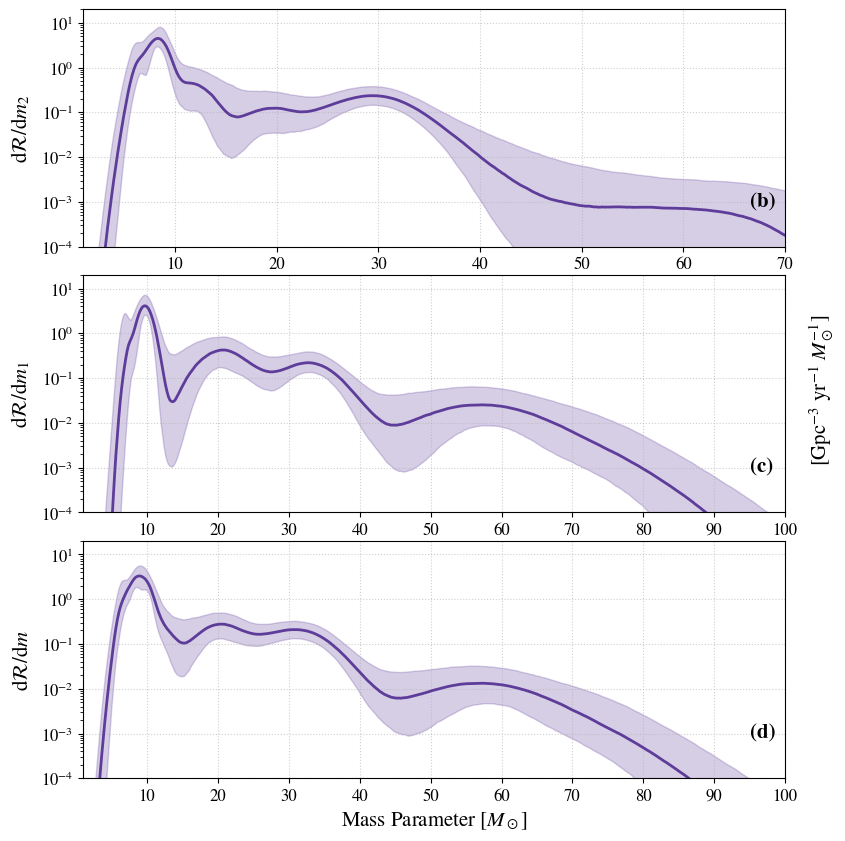

In [8]:
# -----------------------------------------------------------
#  HELPER: COMPUTE INTERVALS + AUTO YLIMS
# -----------------------------------------------------------
def compute_intervals(pdfs, rate):
    diff_rate = np.transpose(rate * np.transpose(pdfs))
    p5 = np.percentile(diff_rate, 5.0, axis=0)
    p50 = np.percentile(diff_rate, 50.0, axis=0)
    p95 = np.percentile(diff_rate, 95.0, axis=0)
    return p5, p50, p95

key = 'o4b'
# -----------------------------------------------------------
#  CREATE FIGURE
# -----------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 10.8 * 0.8), sharex=False)
# =====================================================
# (d) Secondary Mass
# =====================================================
ax = axes[0]
p5, p50, p95 = compute_intervals(pdfs_m2, samples['rate'])
ax.plot(mass_ax, p50, lw=2, color=colours[key])
ax.fill_between(mass_ax, p5, p95, color=colours[key], alpha=0.25)
ax.set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m_2$")
ax.set_xlim(1, 70)
ax.set_ylim(1e-4, 20)
ax.set_yscale('log')
ax.grid(ls=':', alpha=0.6)
ax.text(0.95, 0.17, "(b)", transform=ax.transAxes, fontweight='bold')

# =====================================================
# (c) Primary Mass
# =====================================================
ax = axes[1]
p5, p50, p95 = compute_intervals(pdfs_m1, samples['rate'])
ax.plot(mass_ax, p50, lw=2, color=colours[key])
ax.fill_between(mass_ax, p5, p95, color=colours[key], alpha=0.25)
ax.set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m_1$")
ax.set_xlim(1, 100)
ax.set_xticks([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0])
ax.set_ylim(1e-4, 20)
ax.set_yscale('log')
ax.grid(ls=':', alpha=0.6)
ax.text(0.95, 0.17, "(c)", transform=ax.transAxes, fontweight='bold')

# =====================================================
# (b) Component Mass
# =====================================================
ax = axes[2]
p5, p50, p95 = compute_intervals(pdfs_m, samples['rate'])
ax.plot(mass_ax, p50, lw=2, color=colours[key])
ax.fill_between(mass_ax, p5, p95, color=colours[key], alpha=0.25)
ax.set_xlabel("Mass Parameter [$M_\\odot$]")
ax.set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m$")
ax.set_xlim(1, 100)
ax.set_xticks([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0])
ax.set_ylim(1e-4, 20)
ax.set_yscale('log')
ax.grid(ls=':', alpha=0.6)
ax.text(0.95, 0.17, "(d)", transform=ax.transAxes, fontweight='bold')

# -----------------------------------------------------------
#  ADD SHARED Y-AXIS UNIT LABEL (ON RIGHT)
# -----------------------------------------------------------
fig.text(
    0.96, 0.53,
    r"[Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]",
    va='center', ha='center', rotation='vertical'
)

# -----------------------------------------------------------
#  LAYOUT OPTIMIZATION
# -----------------------------------------------------------
fig.subplots_adjust(
    left=0.14, right=0.92,  # leave room for units on right
    top=0.97, bottom=0.08,
    hspace=0.28  # extra space after chirp-mass panel
)
# fine-tune vertical gaps between lower panels
plt.subplots_adjust(hspace=0.12)

for ax in axes:
    ax.yaxis.labelpad = 6

plt.savefig(directory + '/merger_rate_mass_distributions.png',
            dpi=200, bbox_inches='tight')

In [9]:
#Location of peaks
fac = 1.9
f = 2 ** 0.2 * 1.9 ** 0.6 / 2.9 ** 0.2
pos = {}
pos[1] = {}
pos[1][1] = 7.5
pos[1][2] = f*pos[1][1]
pos[2] = {}
pos[2][2] = pos[1][1] * fac
pos[2][3] = f*pos[2][2]
pos[3] = {}
pos[3][3] = pos[2][2] * fac
pos[3][4] = f*pos[3][3]
pos[4] = {}
pos[4][4] = pos[3][3] * fac

/tmp/ipykernel_2641/4224798672.py:4: UserWarning: Log scale: values of z <= 0 have been masked
  ax1 = plt.contourf(m1m2_xy, m1m2_yx, mean_dRdm1dm2,levels=l, cmap=plt.cm.gist_ncar_r, norm = mpl.colors.LogNorm())
/tmp/ipykernel_2641/4224798672.py:17: UserWarning: Log scale: values of z <= 0 have been masked
  ax1 = plt.contourf(X, Y, R,levels=l, cmap=plt.cm.gist_ncar_r, norm = mpl.colors.LogNorm())


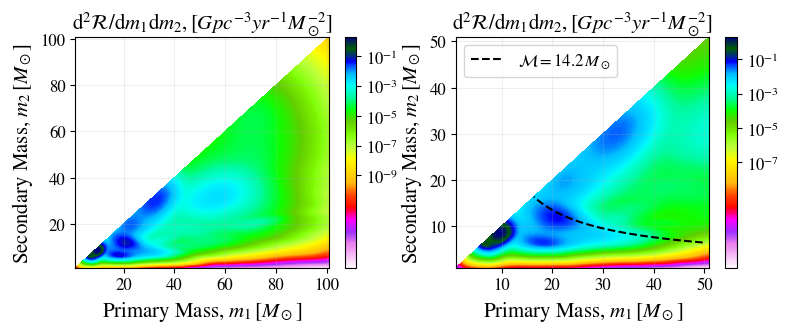

In [10]:
fig = plt.figure(figsize = (9.0, 3.0))
plt.subplot(1, 2, 1)
l = np.exp(np.linspace(np.log(mean_dRdm1dm2[mean_dRdm1dm2 > 0].min()), np.log(mean_dRdm1dm2.max()), 500))
ax1 = plt.contourf(m1m2_xy, m1m2_yx, mean_dRdm1dm2,levels=l, cmap=plt.cm.gist_ncar_r, norm = mpl.colors.LogNorm())

l = [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
plt.title(r'$\mathrm{d}^2\mathcal{R}/\mathrm{d}m_1\mathrm{d}m_2, [Gpc^{-3}yr^{-1}M_\odot^{-2}]$', fontsize=15)
cbar = plt.colorbar(ticks=l)
plt.xlabel(r'Primary Mass, $m_1\, [M_\odot]$')
plt.ylabel(r'Secondary Mass, $m_2\, [M_\odot]$')
plt.grid(alpha=0.2)
plt.subplot(1, 2, 2)
X = m1m2_xy[0:251, 0:251]
Y = m1m2_yx[0:251, 0:251]
R = mean_dRdm1dm2[0:251, 0:251]
l = np.exp(np.linspace(np.log(R[R > 0].min()), np.log(R.max()), 500))
ax1 = plt.contourf(X, Y, R,levels=l, cmap=plt.cm.gist_ncar_r, norm = mpl.colors.LogNorm())

qax = np.linspace(0.13, 1.0, 100)
m1ax, m2ax = conversions.qmch_to_m1m2(pos[2][2], qax) 
plt.plot(m1ax, m2ax, color='k', linestyle='--', label=r'$\mathcal{M}=' + str(np.round(pos[2][2], 1))+r'\,M_\odot$')

l = [1e-7, 1e-5, 1e-3, 1e-1]
plt.title(r'$\mathrm{d}^2\mathcal{R}/\mathrm{d}m_1\mathrm{d}m_2, [Gpc^{-3}yr^{-1}M_\odot^{-2}]$', fontsize=15)
cbar = plt.colorbar(ticks=l)
plt.xlabel(r'Primary Mass, $m_1\, [M_\odot]$')
plt.ylabel(r'Secondary Mass, $m_2\, [M_\odot]$')
plt.grid(alpha=0.2)
plt.legend(loc='upper left')
plt.savefig(directory + '/dRdm1dm2.jpg', dpi = dpi, bbox_inches = 'tight')

### Plot the chirp mass distribution

In [11]:
# Calculate density on the mch-q plane. Also calculate factor increase in merger rate between z=0 and z=0.5
mch_ax = np.linspace(1.0, 76.0, 751)
q_ax = np.linspace(0.1, 1., 50)

# Chirp mass / q distributions
print('Computing chirp mass / q PDFs...')
mchq_res = compute_mchq_pdfs(samples, mch_ax, q_ax,
                              z_eval=0.5, conversions=conversions)

mchq_res_gap = compute_mchq_pdfs(samples_gap, mch_ax, q_ax,
                              z_eval=0.5, conversions=conversions)

Computing chirp mass / q PDFs...


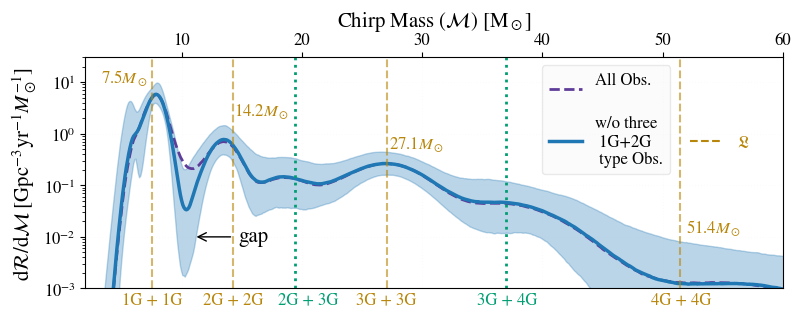

In [12]:
fig, ax = plt.subplots(figsize = (9.0, 3.0))
p5, p50, p95 = compute_intervals(mchq_res['pdfs_mch'], samples['rate'])
plt.plot(mch_ax, p50, linewidth = 2., color = colours['o4b'], label = 'All Obs. \n', linestyle='dashed')
p5, p50, p95 = compute_intervals(mchq_res_gap['pdfs_mch'], samples_gap['rate'])
plt.plot(mch_ax, p50, linewidth = 2.5, color = colours['o4b_gap'], label = 'w/o three \n 1G+2G \n type Obs.')
plt.fill_between(mch_ax, p5, p95, alpha = 0.3, color = colours['o4b_gap'])

plt.xlabel(r'Chirp Mass ($\mathcal{M}$) [$\mathrm{M}_\odot$]')
plt.ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}\mathcal{M}\;[\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}M_\odot^{-1}]$')
plt.xlim(2, 60.)
plt.ylim(1e-3, 30.)
plt.yscale('log')
plt.grid(ls=':', alpha=.04)

if True:
    cintra, cinter = '#B8860B', '#009E73'
    a = 0.6
    plt.axvline(pos[1][1], color = cintra, linestyle='--', alpha=a)
    #plt.axvline(pos[1][2], color = cinter, linestyle=':', linewidth=2.)
    plt.axvline(pos[2][2], color = cintra, linestyle='--', alpha=a)
    plt.axvline(pos[2][3], color = cinter, linestyle=':', linewidth=2.)
    plt.axvline(pos[3][3], color = cintra, linestyle='--', alpha=a)
    plt.axvline(pos[3][4], color = cinter, linestyle=':', linewidth=2.)
    plt.axvline(pos[4][4], color = cintra, linestyle='--', alpha=a)
    mmch = 11.
    plt.annotate(text='', xy=(mmch,.01), xytext=(mmch + 3.3,.01), arrowprops=dict(arrowstyle='->'), color = 'black')
    plt.text(mmch + 3.7, .0081, 'gap')

    shiftx = [4.2, -0.1, -0.2, -0.5]
    ypos = 10.0 * .23** np.arange(4)
    ypos[-1] *= 0.1
    for ii in range(4):
        plt.text(pos[ii+1][ii+1]-shiftx[ii], ypos[ii], str(np.round(pos[ii+1][ii+1], 1))+r'$M_\odot$', color = cintra, fontsize=12)
        ii +=1
        
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    x0 = 5e-4
    plt.text(5.0, x0, '1G + 1G', fontsize=12, color=cintra)
    #plt.text(7.7, x0/2, '1G + 2G', fontsize=12, color=cinter)
    plt.text(11.8, x0, '2G + 2G', fontsize=12, color=cintra)
    plt.text(18., x0, '2G + 3G', fontsize=12, color=cinter)
    plt.text(24.5, x0, '3G + 3G', fontsize=12, color=cintra)
    plt.text(34.6, x0, '3G + 4G', fontsize=12, color=cinter)
    plt.text(49.0, x0, '4G + 4G', fontsize=12, color=cintra)

main_legend = plt.legend(loc='center right', framealpha=0.4, facecolor='#F5F5F5', bbox_to_anchor=(0.85, 0.73))
L_handle = mpl.lines.Line2D([], [], color=cintra, linestyle='--', label=r'$\mathfrak{L}$')
L_legend = plt.legend(handles=[L_handle], loc='center right', frameon=False, bbox_to_anchor=(0.973, 0.63), labelcolor=cintra)
plt.gca().add_artist(main_legend)
plt.savefig(directory + '/confidence_mchirp.jpg', dpi = dpi, bbox_inches = 'tight')

### Plot the mass ratio and aligned spin

In [13]:
sz_ax = np.linspace(-0.99, 0.99, 41)
pdfs_sz = []
rate_ratio_sz = []
for n in range(npost):
    locs_sz = samples['mu_sz'][n]
    stds_sz = samples['sigma_sz'][n]
    gwts = samples['weights'][n]
    k = samples['kcomp'][n]
    pdf_sz, dRdsz_at_z = 0, 0
    if n % 500 == 0:
        print (n)
    for jj in range(ncomp):
        rv = ss.norm(loc = locs_sz[jj], scale = stds_sz[jj])
        nrm = rv.cdf(1) - rv.cdf(-1)
        pdf = rv.pdf(sz_ax) / nrm
        weighted_pdf = pdf * gwts[jj]
        pdf_sz += weighted_pdf
        dRdsz_at_z += weighted_pdf * (1 + 0.5) ** k[jj]

    rate_ratio_sz.append(np.sum(dRdsz_at_z, axis=0) / np.sum(pdf_sz, axis=0))
    pdfs_sz.append(pdf_sz)
rate_ratio_sz = np.array(rate_ratio_sz)
rate_ratio_sz[np.isnan(rate_ratio_sz)] = 0

0
500
1000
1500
2000
2500
3000
3500
4000


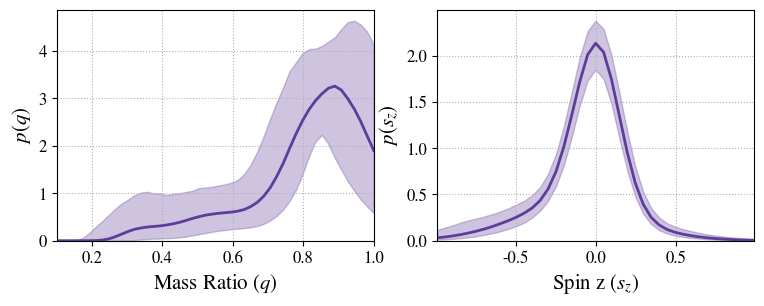

In [14]:
fig = plt.figure(figsize = (9.0, 3.0))
plt.subplot(1, 2, 1)
key = 'o4b'
p5, p50, p95 = compute_intervals(mchq_res['pdfs_q'], 1)
plt.plot(q_ax, p50, color = colours[key], linewidth = 2.0)
plt.fill_between(q_ax, p5, p95, alpha = 0.3, color = colours[key])
plt.grid(ls=':')
plt.ylim(0, None)
plt.xlim(0.1, 1.0)
#plt.yscale('log')
plt.xlabel('Mass Ratio ($q$)')
plt.ylabel('$p(q)$')
plt.subplot(1, 2, 2)
p5, p50, p95 = compute_intervals(pdfs_sz, 1)
plt.plot(sz_ax, p50, color = colours[key], linewidth = 2.0)
plt.fill_between(sz_ax, p5, p95, alpha = 0.3, color = colours[key])
plt.grid(ls=':')
plt.ylim(0, None)
plt.xlim(-0.99, 0.99)
plt.xlabel('Spin z ($s_z$)')
plt.ylabel('$p(s_z)$')

plt.savefig(directory + '/confidence_q_sz.jpg', dpi = dpi, bbox_inches = 'tight')

### Merger rate and its evolution with redshift

In [15]:
z_ax = np.expm1(np.linspace(np.log(1.), np.log(1. + 1.5), 200))
cz_ax = 0.5 * (z_ax[1:] + z_ax[:-1])
Rz = {}
keys = ['o4b']
for key in keys:
    w = samples['weights']
    rates = samples['rate']
    k = samples['kcomp']
    Rz[key] = []
    for ii in range(npost):
        rz_mixture = 0
        kk = k[ii]
        for jj in range(ncomp):
            rz_mixture += w[ii][jj] * (1 + z_ax) ** kk[jj]
        Rz[key].append(rates[ii] * rz_mixture)

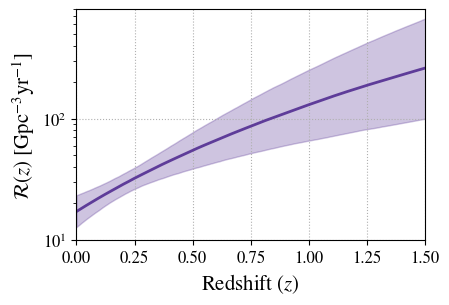

In [16]:
fig = plt.figure(figsize = (4.5, 3.))
p5, p95 = {}, {}
for ii, key in enumerate(keys):
    R = Rz[key]
    p5[key], p50, p95[key] = np.percentile(R, 5., axis = 0), np.percentile(R, 50., axis = 0), np.percentile(R, 95., axis = 0)
    plt.plot(z_ax, p50, linewidth = 2., color = colours[key])
    plt.fill_between(z_ax, p5[keys[0]], p95[keys[0]], alpha = 0.3, color = colours[key])

plt.xlabel(r'Redshift ($z$)')
plt.ylabel(r'$\mathcal{R}(z)$ [$\mathrm{Gpc}^{-3} \mathrm{yr} ^{-1}$]')
plt.yscale('log')
plt.grid(ls=':')
plt.xlim(0, 1.5)
plt.ylim(10, 800)
plt.savefig(directory + '/rate_zevol.jpg', dpi = dpi, bbox_inches = 'tight')

### Draw samples to make correlation plots

In [17]:
# Gridding is 3D is too expensive. Calculate correlations using samples
max_spin = 0.99
ppd = {}
ppd['m1'], ppd['m2'], ppd['sz'] = [], [], []
for ii in range(npost):
    mu_m1 = samples['mu_m1'][ii]
    mu_m2 = samples['mu_m2'][ii]
    sig_m1 = samples['sigma_over_mu_m1_pow_beta'][ii] * mu_m1
    sig_m2 = samples['sigma_over_mu_m2_pow_beta'][ii] * mu_m2
    corr_m1m2 = samples['rho_m1m2'][ii]

    mu_sz = samples['mu_sz'][ii]
    sig_sz = samples['sigma_sz'][ii]
    
    gwts = samples['weights'][ii]
    rate = samples['rate'][ii]

    if ii % 500 == 0:
        print (ii)
    for jj in range(ncomp):
        n = int(160 * gwts[jj] * rate + 0.5)
        mean = np.array([mu_m1[jj], mu_m2[jj]])
        cov = np.diag([sig_m1[jj] ** 2, sig_m2[jj] ** 2])
        cov[0][1] = cov[1][0] = corr_m1m2[jj] * sig_m1[jj] * sig_m2[jj]
        rv = ss.multivariate_normal(mean = mean, cov = cov)

        x = rv.rvs(size=n)
        m1, m2 = x.T

        a, b = (-max_spin - mu_sz[jj]) / sig_sz[jj], (max_spin - mu_sz[jj]) / sig_sz[jj]
        sz = ss.truncnorm.rvs(a = a, b = b, loc = mu_sz[jj], scale = sig_sz[jj], size=n)

        ppd['m1'] = np.append(ppd['m1'], m1)
        ppd['m2'] = np.append(ppd['m2'], m2)
        ppd['sz'] = np.append(ppd['sz'], sz)

idx = np.where((ppd['m2'] / ppd['m1'] < 1) & (np.minimum(ppd['m1'], ppd['m2']) > 0) & (np.abs(ppd['sz']) < max_spin))
ppd['m1'] = ppd['m1'][idx]
ppd['m2'] = ppd['m2'][idx]
ppd['sz'] = ppd['sz'][idx]

0
500
1000
1500
2000
2500
3000
3500
4000


In [18]:
ppd['mch'], ppd['q'] = conversions.m1m2_to_mchq(ppd['m1'], ppd['m2'])
ppd['abs_sz'] = np.abs(ppd['sz'])

mask = np.random.randint(0, 2, size=ppd['m1'].shape).astype(bool)
ppd['m'] = np.where(mask, ppd['m1'], ppd['m2'])

mchax = np.percentile(ppd['mch'], np.linspace(0, 100, 401))
m_ax = np.percentile(ppd['m'], np.linspace(0, 100, 401))

# Calculate the correlations
p5_corr, p50_corr, p95_corr = {}, {}, {}
xax, xvar, yvar = {}, {}, {}
keys = ['qsz', 'm1_abs_sz', 'm_abs_sz', 'mch_abs_sz', 'm1q', 'mq', 'mchq', 'mchcoarseq']

key = 'qsz'
xax[key] = np.percentile(ppd['q'], np.linspace(0, 100, 51))
xvar[key] = 'q'
yvar[key] = 'sz'

key = 'm1_abs_sz'
xax[key] = m_ax
xvar[key] = 'm1'
yvar[key] = 'abs_sz'

key = 'mch_abs_sz'
xax[key] = mchax
xvar[key] = 'mch'
yvar[key] = 'abs_sz'

key = 'm_abs_sz'
xax[key] = m_ax
xvar[key] = 'm'
yvar[key] = 'abs_sz'

key = 'mchq'
xax[key] = mchax
xvar[key] = 'mch'
yvar[key] = 'q'

key = 'm1q'
xax[key] = m_ax
xvar[key] = 'm1'
yvar[key] = 'q'

key = 'mq'
xax[key] = m_ax
xvar[key] = 'm'
yvar[key] = 'q'

key = 'mchcoarseq'
xax[key] = np.linspace(mch_ax[0], mch_ax[-1], 12)
xvar[key] = 'mch'
yvar[key] = 'q'

for key in keys:
    print ('Processing key:', key)
    p5_corr[key], p50_corr[key], p95_corr[key] = [], [], []
    
    for ii in np.arange(len(xax[key]) - 1):
        idx = np.where((ppd[xvar[key]] > xax[key][ii]) & (ppd[xvar[key]] < xax[key][ii+1]))
        
        p5_corr[key] = np.append(p5_corr[key], np.percentile(ppd[yvar[key]][idx], 5.0))
        p50_corr[key] = np.append(p50_corr[key], np.mean(ppd[yvar[key]][idx]))
        p95_corr[key] = np.append(p95_corr[key], np.percentile(ppd[yvar[key]][idx], 95.0))

Processing key: qsz
Processing key: m1_abs_sz
Processing key: m_abs_sz
Processing key: mch_abs_sz
Processing key: m1q
Processing key: mq
Processing key: mchq
Processing key: mchcoarseq


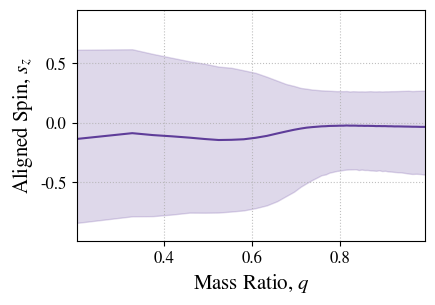

In [19]:
key = 'o4b'
col = colours[key]

key = 'qsz'
fig = plt.figure(figsize = (4.5, 3.0))
ax = 0.5 * (xax[key][1:] + xax[key][:-1])
plt.plot(ax, p50_corr[key], color=col)
plt.fill_between(ax, p5_corr[key], p95_corr[key], alpha=0.2, color=col)
plt.xlim(ax[0], ax[-1])
plt.ylim(-0.99, 0.95)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel('Mass Ratio, $q$')
plt.ylabel('Aligned Spin, $s_z$')
plt.savefig(directory + '/corr_' + key + '.jpg', dpi = dpi, bbox_inches = 'tight')

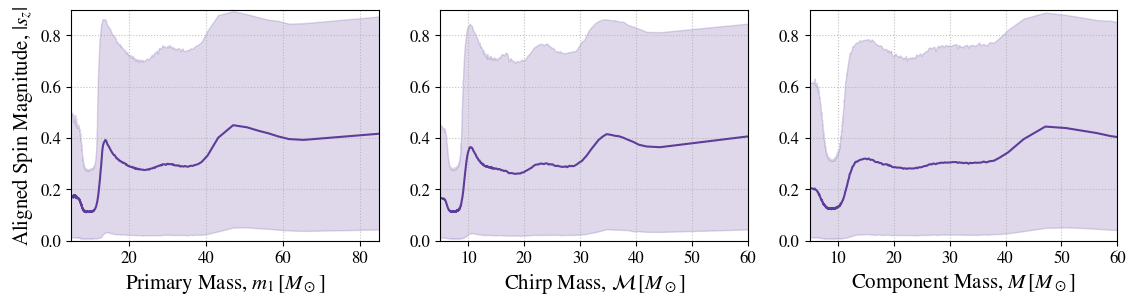

In [20]:
fig = plt.figure(figsize = (13.5, 3.0))
plt.subplot(1, 3, 1)
key1 = 'm1_abs_sz'
ax = 0.5 * (xax[key1][1:] + xax[key1][:-1])
plt.plot(ax, p50_corr[key1], color=col)
plt.fill_between(ax, p5_corr[key1], p95_corr[key1], alpha=0.2, color=col)
plt.xlim(5.0, 85.0)
plt.ylim(0, 0.9)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Primary Mass, $m_1\, [M_\odot]$')
plt.ylabel(r'Aligned Spin Magnitude, $|s_z|$')
plt.subplot(1, 3, 2)
key3 = 'mch_abs_sz'
ax = 0.5 * (xax[key3][1:] + xax[key3][:-1])
plt.plot(ax, p50_corr[key3], color=col)
plt.fill_between(ax, p5_corr[key3], p95_corr[key3], alpha=0.2, color=col)
plt.xlim(5.0, 60.0)
plt.ylim(0, 0.9)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Chirp Mass, $\mathcal{M}\, [M_\odot]$')
#plt.ylabel(r'Aligned Spin Magnitude, $|s_z|$')
plt.subplot(1, 3, 3)
key2 = 'm_abs_sz'
ax = 0.5 * (xax[key2][1:] + xax[key2][:-1])
plt.plot(ax, p50_corr[key2], color=col)
plt.fill_between(ax, p5_corr[key2], p95_corr[key2], alpha=0.2, color=col)
plt.xlim(5.0, 60.0)
plt.ylim(0, 0.9)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Component Mass, $M\, [M_\odot]$')
#plt.ylabel(r'Aligned Spin Magnitude, $|s_z|$')
plt.savefig(directory + '/corr_' + key1 + '_' + key2 + '_' + key3 + '.jpg', dpi = dpi, bbox_inches = 'tight')

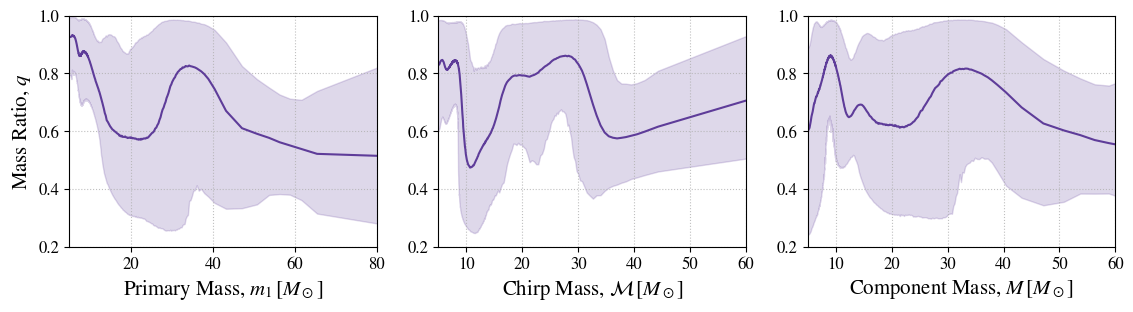

In [21]:
fig = plt.figure(figsize = (13.5, 3.0))
plt.subplot(1, 3, 1)
key1 = 'm1q'
ax = 0.5 * (xax[key1][1:] + xax[key1][:-1])
plt.plot(ax, p50_corr[key1], color=col)
plt.fill_between(ax, p5_corr[key1], p95_corr[key1], alpha=0.2, color=col)
plt.xlim(5.0, 80.0)
plt.ylim(0.2, 1)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Primary Mass, $m_1\, [M_\odot]$')
plt.ylabel(r'Mass Ratio, $q$')
plt.subplot(1, 3, 2)
key3 = 'mchq'
ax = 0.5 * (xax[key3][1:] + xax[key3][:-1])
plt.plot(ax, p50_corr[key3], color=col)
plt.fill_between(ax, p5_corr[key3], p95_corr[key3], alpha=0.2, color=col)
plt.xlim(5.0, 60.0)
plt.ylim(0.2, 1)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Chirp Mass, $\mathcal{M}\, [M_\odot]$')
#plt.ylabel(r'Mass Ratio, $q$')
plt.subplot(1, 3, 3)
key2 = 'mq'
ax = 0.5 * (xax[key2][1:] + xax[key2][:-1])
plt.plot(ax, p50_corr[key2], color=col)
plt.fill_between(ax, p5_corr[key2], p95_corr[key2], alpha=0.2, color=col)
plt.xlim(5.0, 60.0)
plt.ylim(0.2, 1)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Component Mass, $M\, [M_\odot]$')
#plt.ylabel(r'Mass Ratio, $q$')
plt.savefig(directory + '/corr_' + key1 + '_' + key2 + '_' + key3 + '.jpg', dpi = dpi, bbox_inches = 'tight')

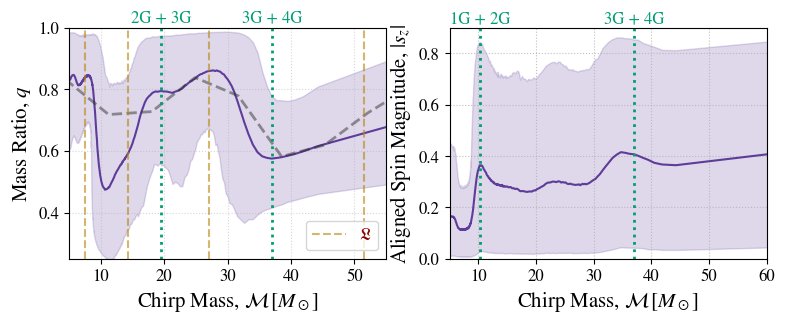

In [22]:
fig = plt.figure(figsize = (4.5 * 2, 3.0))
plt.subplot(1, 2, 1)
key6 = 'mchq'
ax = 0.5 * (xax[key6][1:] + xax[key6][:-1])
plt.plot(ax, p50_corr[key6], color=col)
plt.fill_between(ax, p5_corr[key6], p95_corr[key6], alpha=0.2, color=col)

key6 = 'mchcoarseq'
axx = 0.5 * (xax[key6][1:] + xax[key6][:-1])
plt.plot(axx, p50_corr[key6], color='#333333', linewidth=2, linestyle='--', alpha=.5)
#plt.fill_between(xax[key6][1:], savgol_filter(p5_corr[key6], 5, 1), savgol_filter(p95_corr[key6], 5, 1), alpha=0.2, color='#ff7f0e')

if True:
    a=0.6
    c = cintra
    f = 2 ** 0.2 * 1.9 ** 0.6 / 2.9 ** 0.2
    plt.axvline(pos[1][1], color = c, linestyle='--', label=r'$\mathfrak{L}$', alpha=a)
    plt.axvline(pos[2][2], color = c, linestyle='--', alpha=a)
    plt.axvline(f*pos[2][2], color = '#009E73', linestyle=':', linewidth=2.)
    plt.axvline(pos[3][3], color = c, linestyle='--', alpha=a)
    plt.axvline(f*pos[3][3], color = '#009E73', linestyle=':', linewidth=2.)
    plt.axvline(pos[4][4], color = c, linestyle='--', alpha=a)

    plt.text(14.8, 1.02, '2G + 3G', fontsize=12, color=cinter)
    plt.text(32.3, 1.02, '3G + 4G', fontsize=12, color=cinter)

plt.legend(loc='lower right', labelcolor='darkred')
plt.xlim(5.0, 55.0)
plt.ylim(0.25, 1)
plt.grid(linestyle=':', alpha=0.5)
plt.xlabel(r'Chirp Mass, $\mathcal{M}\, [M_\odot]$')
plt.ylabel(r'Mass Ratio, $q$')

plt.subplot(1, 2, 2)
key3 = 'mch_abs_sz'
ax = 0.5 * (xax[key3][1:] + xax[key3][:-1])
plt.plot(ax, p50_corr[key3], color=col)
plt.fill_between(ax, p5_corr[key3], p95_corr[key3], alpha=0.2, color=col)

if True:
    plt.axvline(f*pos[1][1], color = '#009E73', linestyle=':', linewidth=2.)
    plt.axvline(f*pos[3][3], color = '#009E73', linestyle=':', linewidth=2.)
    plt.text(5., 0.92, '1G + 2G', fontsize=12, color=cinter)
    plt.text(31.7, 0.92, '3G + 4G', fontsize=12, color=cinter)

plt.xlim(5.0, 60.0)
plt.ylim(0, 0.9)
plt.grid(linestyle=':', alpha=0.8)
plt.xlabel(r'Chirp Mass, $\mathcal{M}\, [M_\odot]$')
plt.ylabel(r'Aligned Spin Magnitude, $|s_z|$')
plt.savefig(directory + '/corr_' + key6 + '_' + key3 + '.jpg', dpi = dpi, bbox_inches = 'tight')

### Redshift evolution of massses and spins

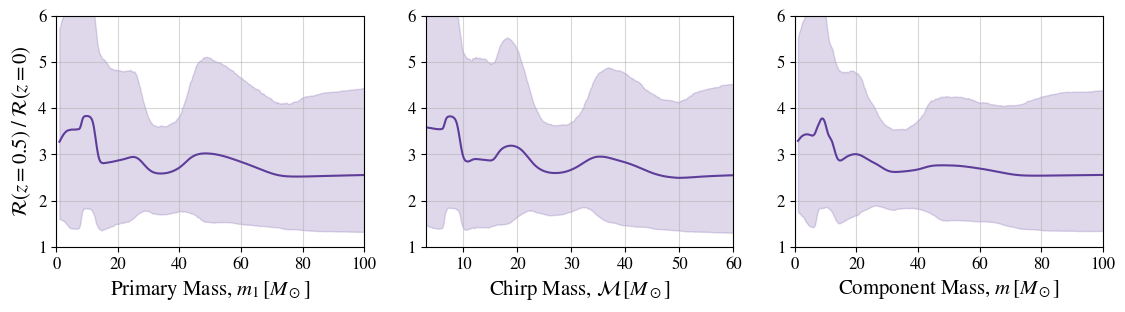

In [23]:
fig = plt.figure(figsize = (13.5, 3.0))
plt.subplot(1, 3, 1)
plt.plot(mass_ax, np.mean(rate_ratio_m1, axis=0), color=col)
plt.fill_between(mass_ax, np.percentile(rate_ratio_m1, 5.0, axis=0), np.percentile(rate_ratio_m1, 95.0, axis=0), alpha=0.2, color=col)
plt.grid(alpha=0.5)
plt.xlim(0, 100)
plt.ylim(1, 6)
plt.xlabel(r'Primary Mass, $m_1\, [M_\odot]$')
plt.ylabel(r'$\mathcal{R}(z=0.5)\;/\;\mathcal{R}(z=0)$')
plt.subplot(1, 3, 2)
plt.plot(mch_ax, np.mean(mchq_res['rate_ratio_mch'], axis=0), color=col)
plt.fill_between(mch_ax, np.percentile(mchq_res['rate_ratio_mch'], 5.0, axis=0), np.percentile(mchq_res['rate_ratio_mch'], 95.0, axis=0), alpha=0.2, color=col)
plt.xlabel(r'Chirp Mass, $\mathcal{M}\, [M_\odot]$')
#plt.ylabel(r'$\mathcal{R}(z=0.5)\;/\;\mathcal{R}(z=0)$')
plt.grid(alpha=0.5)
plt.xlim(3, 60)
plt.ylim(1, 6)
plt.subplot(1, 3, 3)
rate_ratio_m = 0.5 * (np.array(rate_ratio_m1) + np.array(rate_ratio_m2))
plt.plot(mass_ax, np.mean(rate_ratio_m, axis=0), color=col)
plt.fill_between(mass_ax, np.percentile(rate_ratio_m, 5.0, axis=0), np.percentile(rate_ratio_m, 95.0, axis=0), alpha=0.2, color=col)
plt.grid(alpha=0.5)
plt.xlim(0, 100)
plt.ylim(1, 6)
plt.xlabel(r'Component Mass, $m\, [M_\odot]$')
#plt.ylabel(r'$\mathcal{R}(z=0.5)\;/\;\mathcal{R}(z=0)$')
plt.savefig(directory + '/rate_evol_with_mass.jpg', dpi = dpi, bbox_inches = 'tight')

In [24]:
rate_ratio_sz = []
for ii in range(npost):

    mu_sz = samples['mu_sz'][ii]
    sig_sz = samples['sigma_sz'][ii]
    
    gwts = samples['weights'][ii]
    k = samples['kcomp'][ii]
    
    pdfsz, dRdsz_at_z = 0, 0
    for jj in range(ncomp):
        a, b = (-max_spin - mu_sz[jj]) / sig_sz[jj], (max_spin - mu_sz[jj]) / sig_sz[jj]
        pdf = ss.truncnorm.pdf(sz_ax, a = a, b = b, loc = mu_sz[jj], scale = sig_sz[jj]) * gwts[jj]
        pdfsz += pdf#differential rate at z=0 for rate=1
        dRdsz_at_z += pdf * 1.5 ** k[jj]#differential rate at z=0.5 for (rate=1 at z=0)
    
    rate_ratio_sz.append(dRdsz_at_z / pdfsz)

rate_ratio_sz = np.array(rate_ratio_sz)
rate_ratio_sz[np.isnan(rate_ratio_sz)] = 0

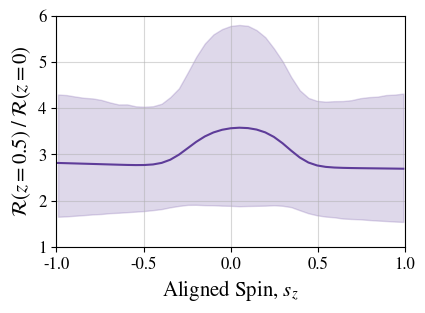

In [25]:
fig = plt.figure(figsize = (4.5, 3.0))
plt.plot(sz_ax, np.mean(rate_ratio_sz, axis=0), color=col)
plt.fill_between(sz_ax, np.percentile(rate_ratio_sz, 5.0, axis=0), np.percentile(rate_ratio_sz, 95.0, axis=0), alpha=0.2, color=col)
plt.xlim(-1, 1)
plt.ylim(1, 6)
plt.grid(alpha=0.5)
plt.xlabel(r'Aligned Spin, $s_z$')
plt.ylabel(r'$\mathcal{R}(z=0.5)\;/\;\mathcal{R}(z=0)$')
plt.savefig(directory + '/rate_evol_with_spin.jpg', dpi = dpi, bbox_inches = 'tight')